# Defect concentrations

Defect concentrations are a crucial piece of information that we can extract with point defects thermodynamics. The function to compute defect concentration is defined at the `DefectEntry` level ([Entries](./entries.ipynb)). When using the ideal solution approach in thermodynamic equilibrium, the number of defects $n$ is equal to:

$$ n = N \; e^{- \beta \Delta G_f} $$

where $\Delta G_f$ is the Gibbs energy of formation, $N$ is the number of lattice sites and $\beta$ is $1/k_B T$. 
Depending on how we express $N$, we obtain the concentrations either per unit volume (conventionally in $\mathrm{cm}^-3$) or per unit cell.

In this tutorial, we learn how to analyse concentrations collectively, when looking at a collection of individual defect entries with the `DefectsAnalysis` class. First, we initialize the class with our usual example.

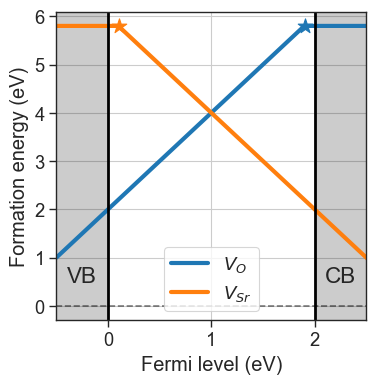

In [44]:
import pandas as pd
from defermi import DefectsAnalysis

bulk_volume = 800 # cubic Amstrong
data = [
{'name': 'Vac_O','charge': 2,'multiplicity': 1,'energy_diff': 7,'bulk_volume': bulk_volume},
{'name': 'Vac_O','charge':0,'multiplicity':1,'energy_diff': 10.8, 'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': -2,'multiplicity': 1,'energy_diff': 8,'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': 0,'multiplicity': 1,'energy_diff': 7.8,'bulk_volume': bulk_volume},
]
df = pd.DataFrame(data)
da = DefectsAnalysis.from_dataframe(df,band_gap=2.0,vbm=0.0)

chempots = {'O':-5,'Sr':-2}
da.plot_formation_energies(chempots,figsize=(4,4));

Defect concentrations can be computed for all entries with the `defect_concentrations` method. Since concentrations depend on the formation energies, we need to provide the chemical potentials and the Fermi level.\
The output is a `DefectConcentrations` object, which behaves as a list of dictionaries, with keys:
- `"name"`
- `"charge"`
- `"conc"` : Concentration value

In [45]:
conc = da.defect_concentrations(chemical_potentials={'O':-5,'Sr':-2},temperature=1000,fermi_level=1)
conc

[charge=0.0, conc=7.35e-09, name=Vac_O
charge=2.0, conc=8.67e+00, name=Vac_O
charge=-2.0, conc=8.67e+00, name=Vac_Sr
charge=0.0, conc=7.35e-09, name=Vac_Sr]

The object provides functionalities and attributes to collectively analyse the concentrations. For example:
- `total`: Sum concentrations of all charge states for each defect, returns a dictionary as `{name:total_conc}`
- `stable`: Return only the stable charge states for each defect, returns another `DefectConcentrations` object
- `elemental`: Sum concentrations of all defects in all charge states for each element. Vacancies of an element are considered a separate element

Use `select_concentrations` to filter desired concentrations based on several attributes, like `name` and `charge`.

In [46]:
print(f"Total concentrations:\n {conc.total}\n")
print(f"Stable charge states concentrations:\n {conc.stable}\n")
print(f"Concentrations of each element:\n {conc.elemental}\n")

print(f"Concentrations of Vac_O with q = +2: {conc.select_concentrations(name='Vac_O',charge=2)}")

Total concentrations:
 {'Vac_O': np.float64(8.66557273790188), 'Vac_Sr': np.float64(8.66557273790188)}

Stable charge states concentrations:
 [charge=2.0, conc=8.67e+00, name=Vac_O
charge=-2.0, conc=8.67e+00, name=Vac_Sr]

Concentrations of each element:
 {'Vac_O': np.float64(8.66557273790188), 'Vac_Sr': np.float64(8.66557273790188)}

Concentrations of Vac_O with q = +2: [charge=2.0, conc=8.67e+00, name=Vac_O]


### Fixed concentrations

When we dope a material, we introduce extrinsic defects into the lattice. The behaviour of such defects can be computed and modelled in the same way as the intrinsic ones. However, the concentrations are determined at the synthesis stage and not in thermodynamic equilibrium with a reservoir. On the other hand, electronic carriers are mobile and can equilibrate, meaning that the charge states of such defects will still depend on temperature and Fermi level. Given a defect $D$ in charge state $q$, its concentration in fixed conditions can be computed as:

$$ [D_q^{fix}] = [D_q] \cdot \frac{[s^{fix}]}{[s]} $$
where $[s]$ is the total concentration of the species in equilibrated conditions, and $[s^{fix}]$ is the target concentration. The same approach can be extended to defect complexes:

$$ [C_q ^{fix}] = [C_q] \cdot \prod_{D\in D^f} \frac{[s^{fix}]}{[s]} = N_C e^{-\beta E_{C,q}} \cdot \prod_{D\in D^f} \frac{[s^{fix}]}{[s]} $$
where the index $D$ refers to single defects that are part of the complex, and $D^f$ indicates the subset of these defects whose concentrations are fixed. More details can be found [here](https://tuprints.ulb.tu-darmstadt.de/24481/) (DOI: 10.26083/tuprints-00024481).

Let's create an example and extend our defects dataset with subsitutional defects, with $\mathrm{SrTiO}_3$ as reference material. We include substitutions with $\mathrm{Fe}$ both on $\mathrm{Sr}$ and on $\mathrm{Ti}$ sites.  


In [47]:
data = [
{'name': 'Vac_O','charge': 2,'multiplicity': 1,'energy_diff': 7,'bulk_volume': bulk_volume},
{'name': 'Vac_O','charge':0,'multiplicity':1,'energy_diff': 10.8, 'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': -2,'multiplicity': 1,'energy_diff': 8,'bulk_volume': bulk_volume},
{'name': 'Vac_Sr','charge': 0,'multiplicity': 1,'energy_diff': 7.8,'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Sr','charge': -1,'multiplicity': 1,'energy_diff': 3.9,'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Sr','charge':0,'multiplicity':1,'energy_diff': 3.5, 'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Ti','charge': 1,'multiplicity': 1,'energy_diff': 7.0,'bulk_volume': bulk_volume},
{'name': 'Sub_Fe_on_Ti','charge': 2,'multiplicity': 1,'energy_diff': 6.5,'bulk_volume': bulk_volume},
]
df = pd.DataFrame(data)
da = DefectsAnalysis.from_dataframe(df,band_gap=2.0,vbm=0.0)
da.table(display=['energy_diff'])

,name,delta atoms,charge,multiplicity,corrections,energy_diff
0,Sub_Fe_on_Sr,"{'Fe': 1, 'Sr': -1}",-1,1,{},3.9
1,Sub_Fe_on_Sr,"{'Fe': 1, 'Sr': -1}",0,1,{},3.5
2,Sub_Fe_on_Ti,"{'Fe': 1, 'Ti': -1}",1,1,{},7.0
3,Sub_Fe_on_Ti,"{'Fe': 1, 'Ti': -1}",2,1,{},6.5
4,Vac_O,{'O': -1},0,1,{},10.8
5,Vac_O,{'O': -1},2,1,{},7.0
6,Vac_Sr,{'Sr': -1},-2,1,{},8.0
7,Vac_Sr,{'Sr': -1},0,1,{},7.8


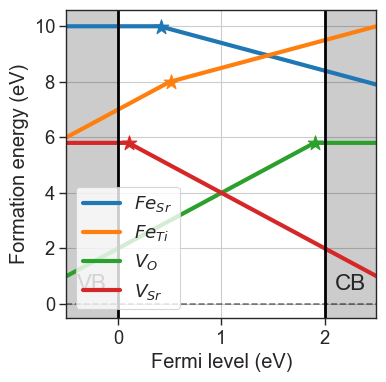

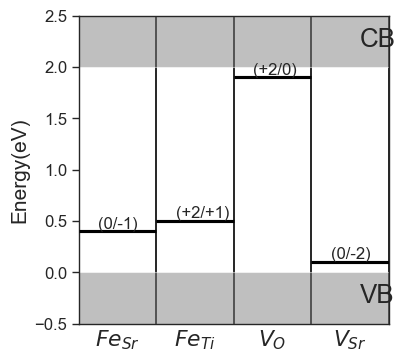

In [48]:
chempots = {'O':-5,'Sr':-2,'Fe':-8.5,'Ti':-8}
da.plot_formation_energies(chempots,figsize=(4,4));
da.plot_ctl(figsize=(4,4),fontsize=12);

Concentrations can be fixed by setting the `fixed_concentrations` argument. We must pass a dictionary with the labels for the target species as keys, and the target concentrations as values. If the key corresponds to the same of a defect species present in our entries, only that defect will be fixed (e.g. `{'Sub_Fe_on_Ti':1e18}`). If the key is the element string, the total concentration of the element is fixed, and the concentration is distributed to the defects containing the element (e.g. `{'Fe':1e18}`).

In [49]:
fixed_concentrations = {'Sub_Fe_on_Ti':1e18} # cm^-3
conc = da.defect_concentrations(
                        chemical_potentials=chempots,
                        temperature=1000,
                        fermi_level=0.5,
                        fixed_concentrations=fixed_concentrations)
conc.select_concentrations(name='Sub_Fe_on_Ti')

[charge=1.0, conc=5.00e+17, name=Sub_Fe_on_Ti,
 charge=2.0, conc=5.00e+17, name=Sub_Fe_on_Ti]

The charge transition level for $\mathrm{Fe_{Ti}}$ is at $E = 0.5$ eV, therefore if the Fermi level is $0.5$ eV, the concentration of $\mathrm{Fe_{Ti}}$ is distributed equally across the two charge states.

We can also fix the concentration of $\mathrm{Fe}$ and let it equilibrate across $\mathrm{Fe_{Ti}}$ and $\mathrm{Fe_{Sr}}$.

In [50]:
fixed_concentrations = {'Fe':1e18}
conc = da.defect_concentrations(
                        chemical_potentials=chempots,
                        temperature=1000,
                        fermi_level=1.5,
                        fixed_concentrations=fixed_concentrations)
conc.select_concentrations(names=['Sub_Fe_on_Ti','Sub_Fe_on_Sr'])

[charge=-1.0, conc=7.61e+17, name=Sub_Fe_on_Sr,
 charge=0.0, conc=2.18e+12, name=Sub_Fe_on_Sr,
 charge=1.0, conc=2.39e+17, name=Sub_Fe_on_Ti,
 charge=2.0, conc=2.18e+12, name=Sub_Fe_on_Ti]

Here we set the Fermi level at $1.5$ eV, where the relative formation energies of $\mathrm{Fe_{Ti}}$ and $\mathrm{Fe_{Sr}}$ are almost equal, therefore the fixed concentration of $10^{18} \mathrm{cm}^{-3}$ is distributed on both defects.

In [51]:
conc.total # total concentrations of all defect species

{'Sub_Fe_on_Sr': np.float64(7.614136635595894e+17),
 'Sub_Fe_on_Ti': np.float64(2.3858633644041062e+17),
 'Vac_O': np.float64(7.907868620633834e-05),
 'Vac_Sr': np.float64(949675.9874314786)}

In [53]:
conc.elemental # total concentrations of all elements across species

{'Fe': np.float64(1e+18),
 'Vac_O': np.float64(7.907868620633834e-05),
 'Vac_Sr': np.float64(949675.9874314786)}